In [10]:
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim

## Cut-DeepONet - (with exact solution dataset)

-, Step 1: Load data - and Piecewise Cutting \
-, Step 2: Training \
-, Step 3: Cutting Net Loading \
-, Step 4: Test performance & Tracking

#### Step 1: Load data (makes the avoid discontinuity output have the same length)

In [11]:
N_data = 250
data = np.load(f"data/exact_solution_dataset_N_{N_data}_one_discontinuity.npz", allow_pickle=True)
discon_data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity.npz")

input_data, output_data = data["X"], data["Y"]
discon_x_data = discon_data["Y"].astype(np.float32)
x = data["x"]
t_domain = data["t"]

#### Lift the dimension of coordinate [X, T] -> [X, T, H(X,T)]

In [12]:
# Lifting at the discontinuity locations - check the x sample at the left or right of the discontinuity location at time step t_idx
def H(coords_np, discon_coords):
    x = coords_np[:, 0]
    return (x >= discon_coords.squeeze()).astype(np.float32)

N, Nx, Nt = input_data.shape[0], x.shape[0], t_domain.shape[0]

xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
base_coords = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
coords_np = np.broadcast_to(base_coords[None, :, :], (N, base_coords.shape[0], 2))  # (N, Nt*Nx, 2)

lifted_coords_np = []
for idx in range(N):
    discon_coords = np.repeat(discon_x_data[idx], Nx, axis=1).reshape(-1, 1)  # (Nt*Nx, 1)
    Hx = H(coords_np[idx], discon_coords)  # (Nt*Nx,)
    lifted_coords_np.append(np.concatenate([coords_np[idx], Hx[:, None]], axis=1))  # (Nt*Nx, 3)

lifted_coords_np = np.array(lifted_coords_np)  # (N, Nt*Nx, 3)
print("Lifted coordinates shape:", lifted_coords_np.shape)  # (N, Nt*Nx, 3) [x, t, H(x,t)]

Lifted coordinates shape: (250, 1000000, 3)


#### Step 2: Training Cut-DeepONet

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# 1) Prepare data
# ---------------------------
# train/val split
rng = np.random.default_rng(42)
all_idx = np.arange(N)
rng.shuffle(all_idx)
n_train = int(0.9 * N) # 90% for training, 10% for validation

train_idx, val_idx = all_idx[:n_train], all_idx[n_train:]

# ---------------------------
# 2) Define Cut-DeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepONet(nn.Module):
    def __init__(self, branch_in, trunk_in=3, latent_dim=128, hidden_dim=256, depth=3):
        super().__init__()
        self.branch = MLP(branch_in, hidden_dim, latent_dim, depth=depth)
        self.trunk = MLP(trunk_in, hidden_dim, latent_dim, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, branch_input, lifted_trunk_input):
        # branch_input: (B, Nx), lifted_trunk_input: (B, P, 2)
        b = self.branch(branch_input)      # (B, latent)

        # Trunk with lifted domain input
        t = self.trunk(lifted_trunk_input)     # (B, P, latent)
        y = torch.einsum('bl,bpl->bp', b, t) + self.bias  # (B, P)
        return y

model = DeepONet(branch_in=Nx, latent_dim=256, hidden_dim=256, depth=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 300
batch_size = 8 # Have to use batch_size is 1, because each case u_0, we have different location of output sampling. Thus the coords_np have location different for each case [N, Nt*reduced_Nx, 2]
points_per_step = 4000  # sampled (x,t) points per batch
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_idx), batch_size):
        # Input and Output for the current batch
        batched_idx = train_idx[start:start + batch_size] 
        batched_input = torch.tensor(input_data[batched_idx], dtype=torch.float32, device=device)   # (B, Nx)
        batched_output = torch.tensor(output_data[batched_idx], dtype=torch.float32, device=device) # (B, Nt, reduced-Nx)
        batched_x = torch.tensor(lifted_coords_np[batched_idx], dtype=torch.float32, device=device) # (B, Nt, reduced-Nx) - different for each case because of different location of output sampling

        # Randomly sample points in the (Nt,Nx) domain for training - Dont choose the x at the point has been removed
        point_idx = rng.integers(0, Nx*Nt, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        # Trunk input and target output for the sampled points
        lifted_trunk_input = torch.tensor(batched_x[:, point_idx], dtype=torch.float32, device=device)  # (P, 3)
        output_target = torch.tensor(batched_output[:, t_idx, x_idx], dtype=torch.float32, device=device)  # (P, B)

        optimizer.zero_grad()
        output_pred = model(batched_input, lifted_trunk_input)
        loss = loss_fn(output_pred, output_target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_losses.append(epoch_loss / max(n_batches, 1))

    # quick validation (random sampled points)
    model.eval()
    with torch.no_grad():
        batched_val = val_idx if len(val_idx) <= 32 else rng.choice(val_idx, size=32, replace=False)
        batched_input_val = torch.tensor(input_data[batched_val], dtype=torch.float32, device=device)
        batched_output_val = torch.tensor(output_data[batched_val], dtype=torch.float32, device=device)
        batched_x_val = torch.tensor(lifted_coords_np[batched_val], dtype=torch.float32, device=device)

        point_idx = rng.integers(0, Nx*Nt, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        lifted_trunk_input_val = torch.tensor(batched_x_val[:, point_idx], dtype=torch.float32, device=device)
        output_val_target = torch.tensor(batched_output_val[:, t_idx, x_idx], dtype=torch.float32, device=device)

        output_val_pred = model(batched_input_val, lifted_trunk_input_val)

        val_loss = loss_fn(output_val_pred, output_val_target).item()
        val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_losses[-1]:.6e} | val_loss={val_losses[-1]:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/cut_deeponet_checkpoint.pt")
print("Saved: cut_deeponet_checkpoint.pt")

Epoch    1/300 | train_loss=4.440311e-01 | val_loss=1.884216e-01
Epoch   20/300 | train_loss=6.392847e-03 | val_loss=7.365334e-03
Epoch   40/300 | train_loss=2.773524e-03 | val_loss=2.452229e-03
Epoch   60/300 | train_loss=1.799819e-03 | val_loss=1.329001e-03
Epoch   80/300 | train_loss=1.512338e-03 | val_loss=1.179349e-03
Epoch  100/300 | train_loss=1.410766e-03 | val_loss=1.398123e-03
Epoch  120/300 | train_loss=1.442972e-03 | val_loss=1.510523e-03
Epoch  140/300 | train_loss=1.585542e-03 | val_loss=9.858465e-04
Epoch  160/300 | train_loss=1.345757e-03 | val_loss=1.062904e-03
Epoch  180/300 | train_loss=1.459206e-03 | val_loss=1.457108e-03
Epoch  200/300 | train_loss=1.297258e-03 | val_loss=1.281202e-03
Epoch  220/300 | train_loss=1.338630e-03 | val_loss=1.217394e-03
Epoch  240/300 | train_loss=1.374029e-03 | val_loss=1.090287e-03
Epoch  260/300 | train_loss=1.430851e-03 | val_loss=1.198735e-03
Epoch  280/300 | train_loss=1.400003e-03 | val_loss=1.113333e-03
Epoch  300/300 | train_lo

#### Step 3: Cutting Net Loading

In [15]:
class MLP(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes=[40, 40, 40]):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Rebuild and load model weights
checkpoint_path = "checkpoints/cutting_net_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

cutting_net = MLP(input_data.shape[1], output_data.shape[1]).to(device)
cutting_net.load_state_dict(checkpoint["model_state_dict"])
cutting_net.eval()

MLP(
  (network): Sequential(
    (0): Linear(in_features=1000, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=1000, bias=True)
  )
)

#### Step 4: Test performance & Tracking

In [16]:
def predict_full_field(model, x, t_domain, input_data_test, sample_idx, chunk = 20000):
    # full point for trunk network input
    xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
    coords_np = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    # input for branch network
    input_test = torch.tensor(input_data_test[sample_idx:sample_idx+1], dtype=torch.float32, device=device)  # (1, Nx)

    # Predict discontinuity location & lifting
    discon_x_test = cutting_net(input_test).detach().numpy()  # (1, Nt)
    discon_coords = np.repeat(discon_x_test.reshape(-1, 1), Nx, axis=1).reshape(-1, 1)  # (Nt*reduced_Nx, 1)
    Hx = torch.Tensor(H(coords_np, discon_coords))
    lifted_trunk_input_test = torch.cat([torch.Tensor(coords_np), Hx.unsqueeze(1)], dim=1).unsqueeze(0)  # (P, 3)

    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, coords_np.shape[0], chunk):
            lifted_trunk_batch = lifted_trunk_input_test[:, i:i+chunk, :].to(device)
            p = model(input_test, lifted_trunk_batch).squeeze(0).cpu().numpy()
            preds.append(p)
    pred_flat = np.concatenate(preds).reshape(Nt, Nx)

    return pred_flat, discon_x_test.squeeze()

def error_analysis_all_t(pred, true, xx, pred_discon, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx])) for idx in range(xx.shape[0])])

    left_bound = np.maximum(disc_idx - window_size, 0)
    right_bound = np.minimum(xx.shape[1], disc_idx + window_size + 1)

    # l1_loss - remove the effect of twice the error for two parallel discontinuity
    pred_disc_idx = np.array([np.argmin(np.abs(xx[idx, :] - pred_discon[idx])) for idx in range(xx.shape[0])])
    error_between_discon = np.mean([np.sum(abs_err[i, min(pred_disc_idx[i], disc_idx[i]):max(pred_disc_idx[i], disc_idx[i])+1]) for i in range(abs_err.shape[0])])
    l1_loss_fair = l1_loss - (error_between_discon/abs_err.shape[1])/2 # only get have error caused by the error between two parallel discontinuity

    # l1_loss_mean near discontinuity
    abs_err_near_dis = np.array([abs_err[i, left_bound[i]:right_bound[i]] for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis)

    l1_loss_fair_near_discon = l1_loss_near_discon - (error_between_discon/abs_err_near_dis.shape[1])/2  # only get have error caused by the error between two parallel discontinuity
    
    return l1_loss, l1_loss_near_discon, l1_loss_fair, l1_loss_fair_near_discon, left_bound, right_bound

def error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=5):
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    l1_loss_all, l1_loss_near_discon_all, l1_loss_fair_all, l1_loss_fair_near_discon_all = [], [], [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field, pred_discon = predict_full_field(model, x_test, t_domain_test, input_data_test, sample_idx=sample_id, chunk=20000)
        l1_loss, l1_loss_near_discon, l1_loss_fair, l1_loss_fair_near_discon, _, _ = error_analysis_all_t(pred_field, output_data_test[sample_id], xx, pred_discon, discon_x_data_test[sample_id], window_size=window_size)

        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)
        l1_loss_fair_all.append(l1_loss_fair)
        l1_loss_fair_near_discon_all.append(l1_loss_fair_near_discon)

    return l1_loss_all, l1_loss_near_discon_all, l1_loss_fair_all, l1_loss_fair_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
    
    pred_field, pred_discon = predict_full_field(model, x_test, t_domain_test, input_data_test, sample_idx=sample_id, chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, _, _, left_bound, right_bound = error_analysis_all_t(pred_field, true_field, xx, pred_discon, discon_x_data_test[sample_id], window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    t_plot = 0.07
    t_idx = int(t_plot / (t_domain_test[1] - t_domain_test[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(x_test, input_data_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x_test, pred_field[t_idx], color="red", label="Pred")
    axes[1].plot(x_test, true_field[t_idx], color="blue", linestyle="--", label="True")
    axes[1].axvline(x_test[left_bound[t_idx]], color="green", alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x_test[right_bound[t_idx]], color="green", alpha=0.5)
    axes[1].set_title(f"t={t_domain_test[t_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

In [17]:
N_data = 20
data = np.load(f"data/exact_solution_dataset_N_{N_data}_one_discontinuity_test.npz", allow_pickle=True)
discon_data = np.load(f"data/exact_solution_discontinuity_dataset_N_{N_data}_one_discontinuity_test.npz")

input_data_test, output_data_test = data["X"], data["Y"]
discon_x_data_test = discon_data["Y"].astype(np.float32)
x_test = data["x"]
t_domain_test = data["t"]

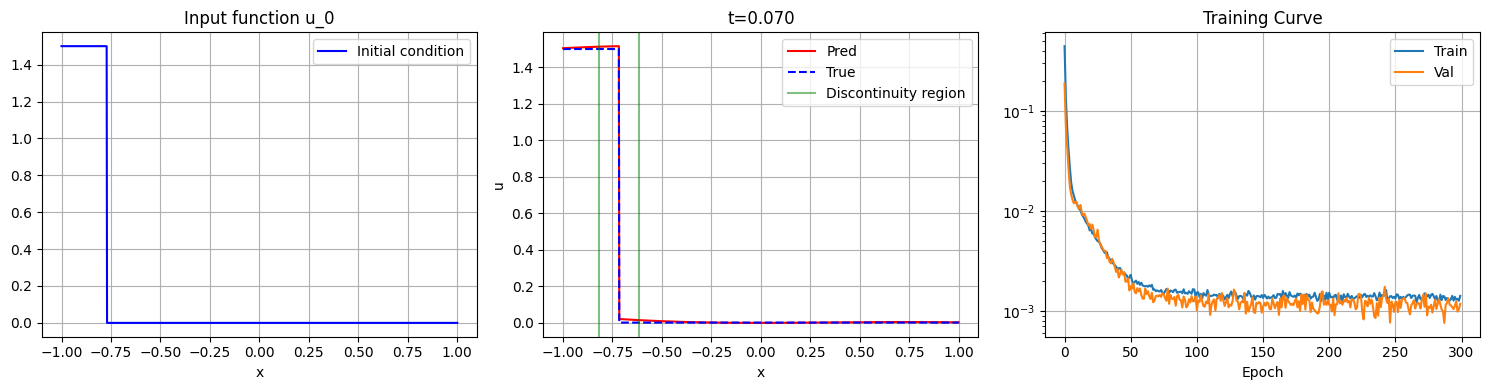

Total parameters: 652,033, trainable parameters: 652,033
L1 Loss (all points): 0.010, std: 0.007
L1 Loss (near discontinuity): 0.053, std: 0.037
L1 Loss (fair): 0.008, std: 0.006
L1 Loss (fair, near discontinuity): 0.033, std: 0.021


In [18]:
# Load the trained Lifted-DeepONet model
checkpoint = torch.load("checkpoints/cut_deeponet_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

l1_loss_all, l1_loss_near_discon_all, l1_loss_fair_all, l1_loss_fair_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=int(0.05 * Nx))
show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id=1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")
print(f"L1 Loss (fair): {np.mean(l1_loss_fair_all):.3f}, std: {np.std(l1_loss_fair_all):.3f}")
print(f"L1 Loss (fair, near discontinuity): {np.mean(l1_loss_fair_near_discon_all):.3f}, std: {np.std(l1_loss_fair_near_discon_all):.3f}")